# Zero-shot performance with custom attention

Does the model still work when its attention is replaced by the hand-made "FC + noise" matrices
built in `custom_attention_construction.ipynb`?

The task is BrainLM's own pretraining objective, used zero-shot: mask exactly one 20-TR patch
per region and score the reconstruction against the real signal with a Pearson r per region.
Two masking conditions, as in the other notebooks in this folder:

- **future** -- the last time patch is masked for every region (forecasting)
- **random** -- a randomly chosen patch per region (interpolation)

Three models, given identical masked tokens so the comparison is paired:

1. **original** -- the unmodified 13M checkpoint
2. **diagonal blocks** -- attention replaced by FC on the grid diagonal, noise elsewhere
3. **diagonal + displaced blocks** -- also FC in the blocks displaced from the grid diagonal

If the custom matrices score close to the original, attention's useful content really is mostly
FC plus noise. The gap between variants 2 and 3 says whether the displaced FC blocks help.

In [1]:
import os
import sys
import csv
import json

MAX_CPU_THREADS = 4
os.environ["OMP_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["MKL_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["OPENBLAS_NUM_THREADS"] = str(MAX_CPU_THREADS)

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import stats

torch.set_num_threads(MAX_CPU_THREADS)
sys.path.insert(0, os.path.abspath(".."))
from run_model import load_brainlm_model, load_spatial_coordinates, preprocess_subject_data
from custom_attention import (noise_schedule, build_custom_attention, make_custom_attention_hook)

get_ipython().run_line_magic("matplotlib", "inline")

In [2]:
INPUT_H5 = "../data/input/fmri_timeseries_subset_100.h5"
COORDS = "../data/input/toolkit/atlases/A424_Coordinates.dat"
HF_REPO, SUBFOLDER = "vandijklab/brainlm", "old_13M"

CUSTOM_DIR = "outputs/custom_attention"
FIGURES_DIR = "figures"
OUTPUTS_DIR = "outputs"
os.makedirs(FIGURES_DIR, exist_ok=True)

fc_store = np.load(os.path.join(CUSTOM_DIR, "fc_matrices.npz"))
with open(os.path.join(CUSTOM_DIR, "params.json")) as f:
    params = json.load(f)

WINDOW_SIZE = params["window_size"]
RANDOM_SEED = params["random_seed"]
NOISE_START_FRACTION = params["noise_start_fraction"]
BLOCK_OFFSET = params["block_offset"]
SUBJECT_IDS = params["subjects"]

print(f"{len(SUBJECT_IDS)} subjects, block displacement {BLOCK_OFFSET}, seed {RANDOM_SEED}")

25 subjects, block displacement 4, seed 0


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, config = load_brainlm_model(HF_REPO, SUBFOLDER)
model.to(device)
model.eval()
spatial_coords = load_spatial_coordinates(COORDS).to(device)

num_regions = config.num_brain_voxels
patch_size = config.timepoint_patching_size
num_patches = WINDOW_SIZE // patch_size
seq_len = num_regions * num_patches
num_layers = config.num_hidden_layers
FUTURE_PATCH = num_patches - 1

# One masked patch per region -> exactly num_regions masked tokens.
model.config.mask_ratio = num_regions / seq_len
print(f"{seq_len} tokens, mask_ratio={model.config.mask_ratio:.3f} -> {num_regions} masked, "
      f"{seq_len - num_regions} kept")

/home/fmoss/miniforge3/envs/brainlm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/fmoss/miniforge3/envs/brainlm/lib/python3.10/site-packages/accelerate/utils/torch_xla.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


loading weights file pytorch_model.bin from cache at /home/fmoss/.cache/huggingface/hub/models--vandijklab--brainlm/snapshots/4c54e0cccf920d9d6af7c647cb866fc19c60cf26/old_13M/pytorch_model.bin


All model checkpoint weights were used when initializing BrainLMForPretraining.



All the weights of BrainLMForPretraining were initialized from the model checkpoint at vandijklab/brainlm.
If your task is similar to the task the model of the checkpoint was trained on, you can already use BrainLMForPretraining for predictions without further training.


4240 tokens, mask_ratio=0.100 -> 424 masked, 3816 kept


## Helpers

In [4]:
def token_index(region, patch):
    """BrainLM's region-major token order."""
    return region * num_patches + patch


def exact_mask_noise(mask_token_indices):
    """Noise vector that makes the model's random_masking mask exactly these tokens."""
    noise = torch.rand(1, seq_len, device=device)                      # kept side, [0, 1)
    idx = torch.as_tensor(mask_token_indices, device=device, dtype=torch.long).unsqueeze(0)
    noise.scatter_(1, idx, 1.0 + torch.rand(1, idx.shape[1], device=device))   # masked side, [1, 2)
    return noise


def per_region_correlation(predicted, masked, window):
    """Pearson r per region, over that region's single masked patch."""
    r_values = np.full(num_regions, np.nan)
    patches_used = np.zeros(num_regions, dtype=int)
    for region in range(num_regions):
        patch = int(np.flatnonzero(masked[region])[0])
        lo, hi = patch * patch_size, (patch + 1) * patch_size
        r_values[region] = np.corrcoef(window[region, lo:hi], predicted[region, patch, :])[0, 1]
        patches_used[region] = patch
    return r_values, patches_used

In [5]:
def predict(x, mask_token_indices, fc_matrix, block_offset, subject_index):
    """Reconstruct the masked patches. block_offset="original" leaves attention untouched;
    otherwise every layer's attention is replaced by the custom FC+noise matrix."""
    noise = exact_mask_noise(mask_token_indices)

    handles = []
    if block_offset != "original":
        # Which tokens survive masking -- the custom matrix must cover exactly those.
        with torch.no_grad():
            _, _, ids_restore = model.vit.embeddings(x, spatial_coords, noise)
        len_keep = seq_len - len(mask_token_indices)
        kept = torch.argsort(ids_restore, dim=1)[0, :len_keep].cpu().numpy()
        kept_regions, kept_patches = kept // num_patches, kept % num_patches

        noise_scales = noise_schedule(float(np.abs(fc_matrix).mean()), num_layers, NOISE_START_FRACTION)
        for layer in range(num_layers):
            rng = np.random.default_rng(RANDOM_SEED + subject_index * 1000 + layer)
            custom = build_custom_attention(fc_matrix, kept_regions, kept_patches,
                                            noise_scales[layer], rng, block_offset)
            handles.append(model.vit.encoder.layer[layer].attention.self.register_forward_hook(
                make_custom_attention_hook(custom)))
    try:
        with torch.no_grad():
            out = model(signal_vectors=x, xyz_vectors=spatial_coords, noise=noise)
    finally:
        for handle in handles:
            handle.remove()

    logits = out.logits[0] if isinstance(out.logits, tuple) else out.logits
    predicted = logits[0].detach().cpu().numpy()
    masked = out.mask[0].detach().cpu().numpy().astype(bool)

    expected = {(i // num_patches, i % num_patches) for i in mask_token_indices}
    if {tuple(rc) for rc in np.argwhere(masked)} != expected:
        raise RuntimeError("the model masked a different token set than requested")
    return predicted, masked


MODELS = {"original": "original", "diagonal blocks": None, "diagonal + displaced blocks": BLOCK_OFFSET}

## One subject, to see what the reconstructions look like

Both masking conditions, all three models, on the same masked patch per condition.

In [6]:
with h5py.File(INPUT_H5, "r") as f:
    all_ids = [s.decode("utf-8") for s in f["subject_ids"][:]]
    demo_index = all_ids.index(SUBJECT_IDS[0])
    raw_demo = f["parcel_ts"][demo_index, :, :]

x_demo = preprocess_subject_data(raw_demo, num_windows=3, window_size=WINDOW_SIZE)[0:1].to(device)
window_demo = raw_demo[:WINDOW_SIZE, :].T
fc_demo = fc_store[SUBJECT_IDS[0]]

# Same masking as the full run below: future masks the last patch everywhere, random draws one
# patch per region from the subject's own seeded generator.
demo_rng = np.random.default_rng(RANDOM_SEED + 0)
demo_conditions = {"future": [token_index(r, FUTURE_PATCH) for r in range(num_regions)],
                   "random": [token_index(r, int(p)) for r, p in
                              enumerate(demo_rng.integers(0, num_patches, size=num_regions))]}

demo_results = {}
for condition, mask_indices in demo_conditions.items():
    for name, offset in MODELS.items():
        predicted, masked = predict(x_demo, mask_indices, fc_demo, offset, demo_index)
        r_values, patches_used = per_region_correlation(predicted, masked, window_demo)
        demo_results[(condition, name)] = (predicted, patches_used, r_values)
        print(f"{condition:7s} {name:28s}: mean r = {np.nanmean(r_values):.3f}")

future  original                    : mean r = -0.016


future  diagonal blocks             : mean r = 0.010


future  diagonal + displaced blocks : mean r = 0.007


random  original                    : mean r = 0.150


random  diagonal blocks             : mean r = 0.223


random  diagonal + displaced blocks : mean r = 0.179


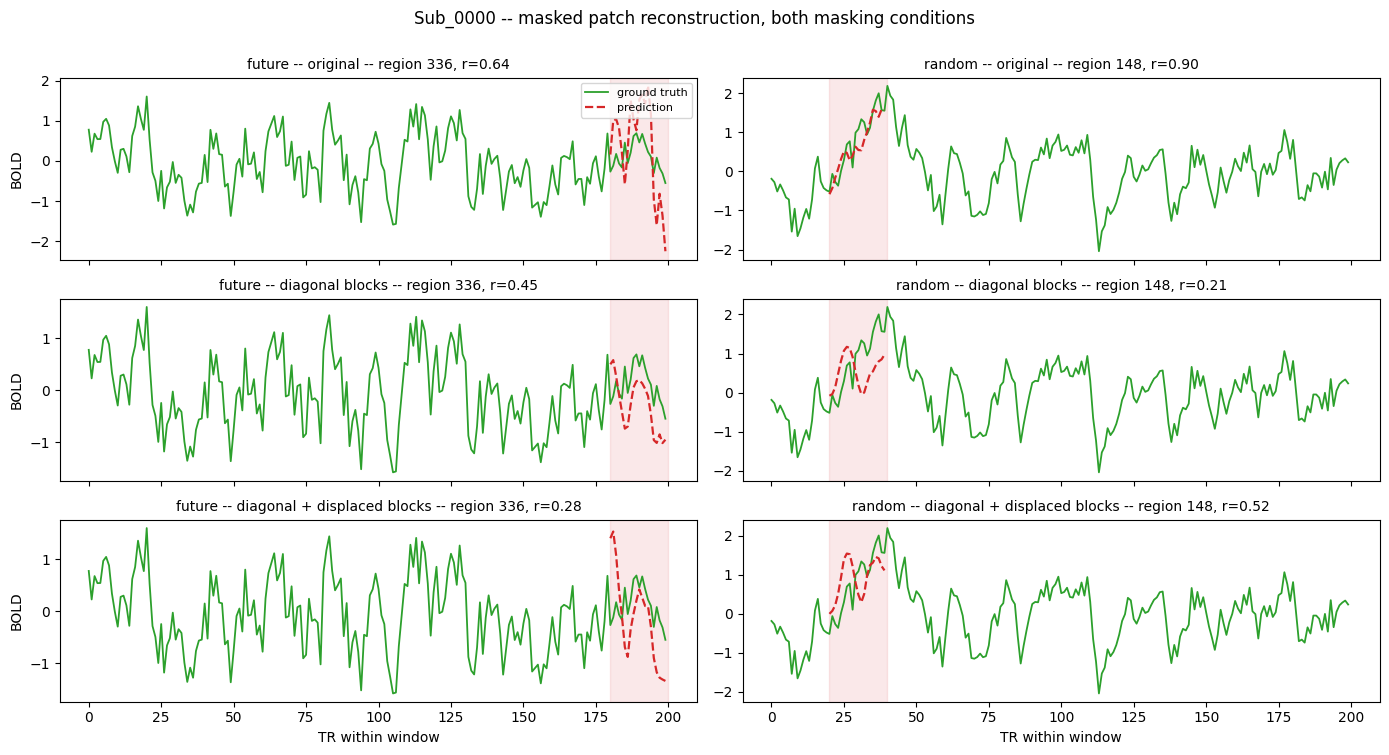

In [7]:
# One region per condition -- the one the original model reconstructs best -- so all three
# models are compared on exactly the same masked patch.
fig, axes = plt.subplots(len(MODELS), len(demo_conditions),
                         figsize=(7 * len(demo_conditions), 2.5 * len(MODELS)), sharex=True)
for col, condition in enumerate(demo_conditions):
    region = int(np.nanargmax(demo_results[(condition, "original")][2]))
    for row, name in enumerate(MODELS):
        predicted, patches_used, r_values = demo_results[(condition, name)]
        patch = patches_used[region]
        lo, hi = patch * patch_size, (patch + 1) * patch_size
        ax = axes[row, col]
        ax.plot(window_demo[region], color="tab:green", linewidth=1.3, label="ground truth")
        ax.plot(range(lo, hi), predicted[region, patch, :], color="tab:red", linewidth=1.6,
                linestyle="--", label="prediction")
        ax.axvspan(lo, hi, color="tab:red", alpha=0.10)
        ax.set_title(f"{condition} -- {name} -- region {region}, r={r_values[region]:.2f}", fontsize=10)
        if col == 0:
            ax.set_ylabel("BOLD")
axes[0, 0].legend(fontsize=8, loc="upper right")
for ax in axes[-1]:
    ax.set_xlabel("TR within window")
fig.suptitle(f"{SUBJECT_IDS[0]} -- masked patch reconstruction, both masking conditions", y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "custom_attention_example_reconstruction.png"), dpi=130, bbox_inches="tight")
plt.show()

## All subjects, both conditions, all three models

Every model sees identical masked tokens for a given (subject, condition), so the comparisons
below are paired. This is the slow cell -- one forward pass per subject x condition x model.

In [8]:
results = []
for subject_index, sub_id in enumerate(SUBJECT_IDS):
    with h5py.File(INPUT_H5, "r") as f:
        h5_index = all_ids.index(sub_id)
        raw = f["parcel_ts"][h5_index, :, :]
    x = preprocess_subject_data(raw, num_windows=3, window_size=WINDOW_SIZE)[0:1].to(device)
    window = raw[:WINDOW_SIZE, :].T
    fc_matrix = fc_store[sub_id]

    rng = np.random.default_rng(RANDOM_SEED + subject_index)
    conditions = {"future": [token_index(r, FUTURE_PATCH) for r in range(num_regions)],
                  "random": [token_index(r, int(p)) for r, p in
                             enumerate(rng.integers(0, num_patches, size=num_regions))]}

    line = [f"{sub_id}:"]
    for condition, mask_indices in conditions.items():
        for name, offset in MODELS.items():
            predicted, masked = predict(x, mask_indices, fc_matrix, offset, h5_index)
            r_values, patches_used = per_region_correlation(predicted, masked, window)
            for region in range(num_regions):
                results.append({"subject_id": sub_id, "region": region, "condition": condition,
                                "model": name, "patch": int(patches_used[region]),
                                "r": float(r_values[region])})
            line.append(f"{condition}/{name}={np.nanmean(r_values):.3f}")
    print("  ".join(line))

print(f"\n{len(results)} rows")

Sub_0000:  future/original=-0.016  future/diagonal blocks=0.006  future/diagonal + displaced blocks=0.006  random/original=0.150  random/diagonal blocks=0.226  random/diagonal + displaced blocks=0.170


Sub_0001:  future/original=-0.024  future/diagonal blocks=0.052  future/diagonal + displaced blocks=0.173  random/original=0.108  random/diagonal blocks=0.220  random/diagonal + displaced blocks=0.208


Sub_0002:  future/original=0.232  future/diagonal blocks=0.183  future/diagonal + displaced blocks=0.431  random/original=0.039  random/diagonal blocks=0.263  random/diagonal + displaced blocks=0.202


Sub_0004:  future/original=-0.042  future/diagonal blocks=-0.038  future/diagonal + displaced blocks=-0.076  random/original=0.251  random/diagonal blocks=0.223  random/diagonal + displaced blocks=0.206


Sub_0005:  future/original=0.166  future/diagonal blocks=0.145  future/diagonal + displaced blocks=0.159  random/original=0.044  random/diagonal blocks=0.293  random/diagonal + displaced blocks=0.288


...

Sub_0021:  future/original=0.136  future/diagonal blocks=0.086  future/diagonal + displaced blocks=0.124  random/original=0.258  random/diagonal blocks=0.286  random/diagonal + displaced blocks=0.241


Sub_0022:  future/original=0.005  future/diagonal blocks=0.041  future/diagonal + displaced blocks=0.037  random/original=0.268  random/diagonal blocks=0.282  random/diagonal + displaced blocks=0.267


Sub_0023:  future/original=-0.058  future/diagonal blocks=0.022  future/diagonal + displaced blocks=0.013  random/original=0.178  random/diagonal blocks=0.250  random/diagonal + displaced blocks=0.224


Sub_0024:  future/original=-0.193  future/diagonal blocks=0.012  future/diagonal + displaced blocks=-0.056  random/original=0.116  random/diagonal blocks=0.232  random/diagonal + displaced blocks=0.232


Sub_0025:  future/original=0.070  future/diagonal blocks=0.069  future/diagonal + displaced blocks=0.127  random/original=0.176  random/diagonal blocks=0.200  random/diagonal + displaced blocks=0.151

63600 rows


In [9]:
csv_path = os.path.join(OUTPUTS_DIR, "custom_attention_zero_shot.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["subject_id", "region", "condition", "model", "patch", "r"])
    writer.writeheader()
    writer.writerows(results)
print(f"saved -> {csv_path}")

saved -> outputs/custom_attention_zero_shot.csv


## Results

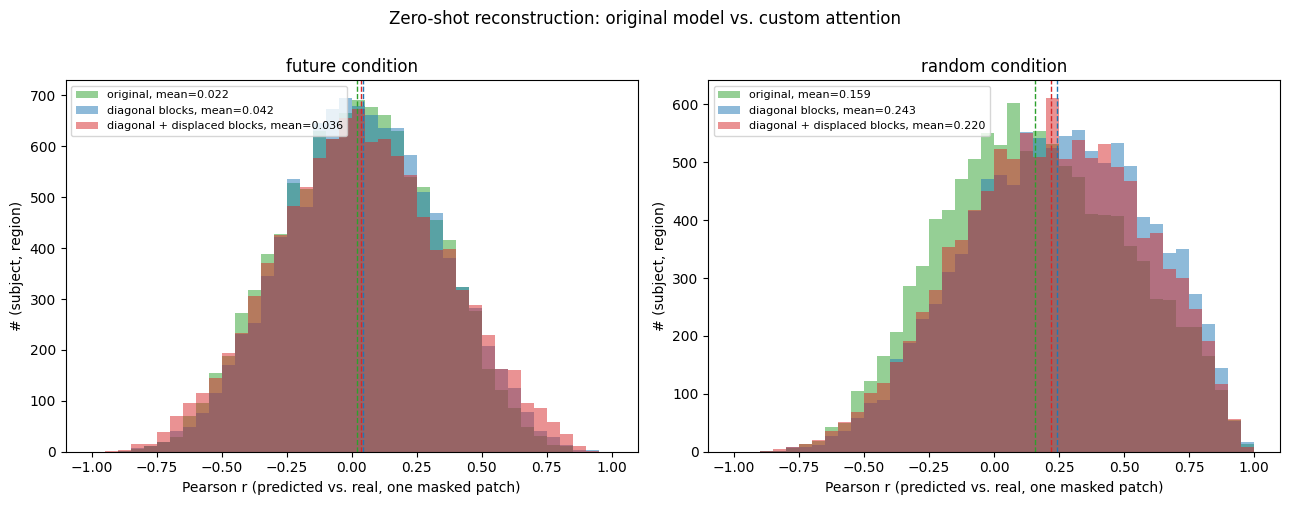

In [10]:
def collect(condition, model):
    return np.array([row["r"] for row in results
                     if row["condition"] == condition and row["model"] == model])


COLORS = {"original": "tab:green", "diagonal blocks": "tab:blue",
          "diagonal + displaced blocks": "tab:red"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bins = np.linspace(-1, 1, 41)
for ax, condition in zip(axes, ["future", "random"]):
    for name in MODELS:
        values = collect(condition, name)
        ax.hist(values, bins=bins, alpha=0.5, color=COLORS[name],
                label=f"{name}, mean={np.nanmean(values):.3f}")
        ax.axvline(np.nanmean(values), color=COLORS[name], linestyle="--", linewidth=1)
    ax.set_xlabel("Pearson r (predicted vs. real, one masked patch)")
    ax.set_ylabel("# (subject, region)")
    ax.set_title(f"{condition} condition")
    ax.legend(fontsize=8)
fig.suptitle("Zero-shot reconstruction: original model vs. custom attention", y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "custom_attention_zero_shot_distributions.png"), dpi=130, bbox_inches="tight")
plt.show()

In [11]:
names = list(MODELS)
for condition in ["future", "random"]:
    print(f"\n{condition}:")
    for name in names:
        values = collect(condition, name)
        print(f"  {name:28s} mean={np.nanmean(values):.3f}  median={np.nanmedian(values):.3f}")
    for a, b in [(names[0], names[1]), (names[0], names[2]), (names[1], names[2])]:
        va, vb = collect(condition, a), collect(condition, b)
        valid = ~(np.isnan(va) | np.isnan(vb))
        statistic, p_value = stats.wilcoxon(va[valid], vb[valid])
        print(f"  {a} vs {b}: paired Wilcoxon n={int(valid.sum())}, p={p_value:.3g}")


future:
  original                     mean=0.022  median=0.026
  diagonal blocks              mean=0.042  median=0.039
  diagonal + displaced blocks  mean=0.036  median=0.031
  original vs diagonal blocks: paired Wilcoxon n=10600, p=2.7e-12
  original vs diagonal + displaced blocks: paired Wilcoxon n=10600, p=1.43e-07
  diagonal blocks vs diagonal + displaced blocks: paired Wilcoxon n=10600, p=0.22

random:
  original                     mean=0.159  median=0.146
  diagonal blocks              mean=0.243  median=0.253
  diagonal + displaced blocks  mean=0.220  median=0.226
  original vs diagonal blocks: paired Wilcoxon n=10600, p=5.77e-174
  original vs diagonal + displaced blocks: paired Wilcoxon n=10600, p=1.48e-79
  diagonal blocks vs diagonal + displaced blocks: paired Wilcoxon n=10600, p=7.3e-34


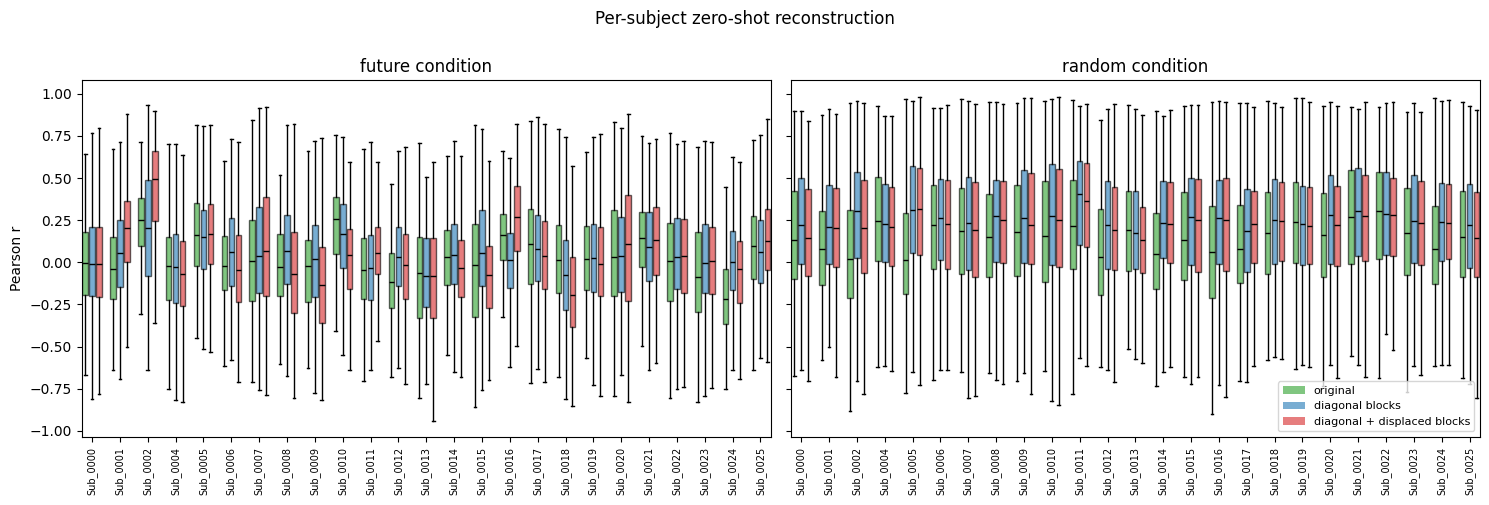

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, condition in zip(axes, ["future", "random"]):
    positions = np.arange(len(SUBJECT_IDS)) * (len(MODELS) + 1)
    for offset_i, name in enumerate(MODELS):
        per_subject = [[row["r"] for row in results
                        if row["subject_id"] == sid and row["condition"] == condition
                        and row["model"] == name] for sid in SUBJECT_IDS]
        bp = ax.boxplot(per_subject, positions=positions + offset_i, widths=0.8,
                        patch_artist=True, showfliers=False,
                        boxprops=dict(facecolor=COLORS[name], alpha=0.6),
                        medianprops=dict(color="black"))
    ax.set_xticks(positions + (len(MODELS) - 1) / 2)
    ax.set_xticklabels(SUBJECT_IDS, rotation=90, fontsize=7)
    ax.set_title(f"{condition} condition")
axes[0].set_ylabel("Pearson r")
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=COLORS[n], alpha=0.6) for n in MODELS]
axes[1].legend(handles, list(MODELS), fontsize=8, loc="lower right")
fig.suptitle("Per-subject zero-shot reconstruction", y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "custom_attention_zero_shot_per_subject.png"), dpi=130, bbox_inches="tight")
plt.show()